In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
#Your objective is to explore the relationship between trader performance and market 
#sentiment, uncover hidden patterns, and deliver insights that can drive smarter trading 
#strategies.


In [148]:
sentiment_data = pd.read_csv("dataset/fear_greed_index.csv")

In [149]:
trade_data= pd.read_csv("dataset/historical_data.csv")

In [150]:
sentiment_data.sample(5)

,timestamp,value,classification,date
1054,1608787800,86,Extreme Greed,2020-12-24
592,1568871000,31,Fear,2019-09-19
1210,1622266200,18,Extreme Fear,2021-05-29
1581,1654320600,14,Extreme Fear,2022-06-04
1220,1623130200,13,Extreme Fear,2021-06-08


In [151]:
sentiment_data.shape

(2644, 4)

In [152]:
sentiment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [153]:
sentiment_data.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [154]:
sentiment_data.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [155]:
sentiment_data.duplicated().sum()

np.int64(0)

In [156]:
sentiment_data['classification'].value_counts()


classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

(array([ 38., 130., 230., 311., 214., 209., 205., 264., 189., 161., 154.,
        297., 116.,  51.,  75.]),
 array([ 5., 11., 17., 23., 29., 35., 41., 47., 53., 59., 65., 71., 77.,
        83., 89., 95.]),
 <BarContainer object of 15 artists>)

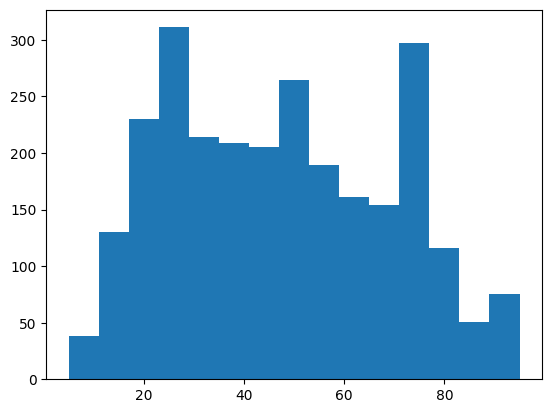

In [157]:
plt.hist(sentiment_data['value'],bins=15) # it gives the range of value

In [158]:
trade_data.sample(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
210914,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.060000,472.70000,501.06,BUY,22-04-2025 16:14,70481.900000,Open Long,0.000000,0x7e9a3281f83802aa3396042206ebf4019400d0b38722...,87986115219,False,5.010600e-02,4.860000e+13,1.750000e+12
205688,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,VIRTUAL,0.725000,36.10000,26.17,SELL,23-04-2025 07:49,-29891.000000,Open Short,0.000000,0xd566002a083524eba4420422118c820206a90068318b...,88174840966,False,1.308000e-03,2.370000e+14,1.750000e+12
370,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AIXBT,0.086894,3513.00000,305.26,SELL,12-04-2025 20:07,97533.000000,Close Long,14.515716,0xdccb756e0d44199b1eae0421681a120205870049e634...,86040314167,True,1.025660e-01,1.390000e+14,1.740000e+12
99764,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,@142,93362.000000,0.00504,470.54,BUY,30-04-2025 19:25,1.317042,Buy,0.000000,0xa33747573c35c793b79504228b0f9f0205f001018710...,89844065525,False,5.040000e-07,5.730000e+14,1.750000e+12
47251,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,HYPE,24.494000,8.17000,200.12,BUY,02-02-2025 03:24,-23628.390000,Close Short,11.544210,0xa6991c5ceab1f8abdae4041cf4f5bb0201e300bf5489...,68322580621,True,7.004000e-02,6.310000e+14,1.740000e+12


In [159]:
trade_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [160]:
trade_data.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [161]:
trade_data.duplicated().sum()

np.int64(0)

In [162]:
trade_data.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [163]:
# timestamp both data
trade_data[["Timestamp IST",'Timestamp']].head()

,Timestamp IST,Timestamp
0,02-12-2024 22:50,1.730000e+12
1,02-12-2024 22:50,1.730000e+12
2,02-12-2024 22:50,1.730000e+12
3,02-12-2024 22:50,1.730000e+12
4,02-12-2024 22:50,1.730000e+12


In [164]:
print(trade_data['Timestamp'].iloc[0]) # it is Unix Milliseconds

1730000000000.0


In [165]:
# we need to convert the timestamp
trade_data['Timestamp IST'] =pd.to_datetime(
    trade_data['Timestamp IST'],
    dayfirst=True)
trade_data['trade_date']= trade_data['Timestamp IST'].dt.date

In [166]:
# sentiment data
sentiment_data['date'] = pd.to_datetime(
    sentiment_data['date']
)

sentiment_data['trade_date'] = sentiment_data['date'].dt.date

# EDA (Trade Dataset)

In [167]:
# trade direction distrbution
trade_data['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [168]:
# Merging both dataset
merged_data = pd.merge(
    trade_data,
    sentiment_data[['trade_date','value','classification']],
    on='trade_date',
    how='inner'
)

In [169]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80,Extreme Greed


## EDA of Merged data

In [170]:
merged_data.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
trade_date          0
value               0
classification      0
dtype: int64

In [171]:
merged_data.shape

(211218, 19)

In [172]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211218 entries, 0 to 211217
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211218 non-null  object        
 1   Coin              211218 non-null  object        
 2   Execution Price   211218 non-null  float64       
 3   Size Tokens       211218 non-null  float64       
 4   Size USD          211218 non-null  float64       
 5   Side              211218 non-null  object        
 6   Timestamp IST     211218 non-null  datetime64[ns]
 7   Start Position    211218 non-null  float64       
 8   Direction         211218 non-null  object        
 9   Closed PnL        211218 non-null  float64       
 10  Transaction Hash  211218 non-null  object        
 11  Order ID          211218 non-null  int64         
 12  Crossed           211218 non-null  bool          
 13  Fee               211218 non-null  float64       
 14  Trad

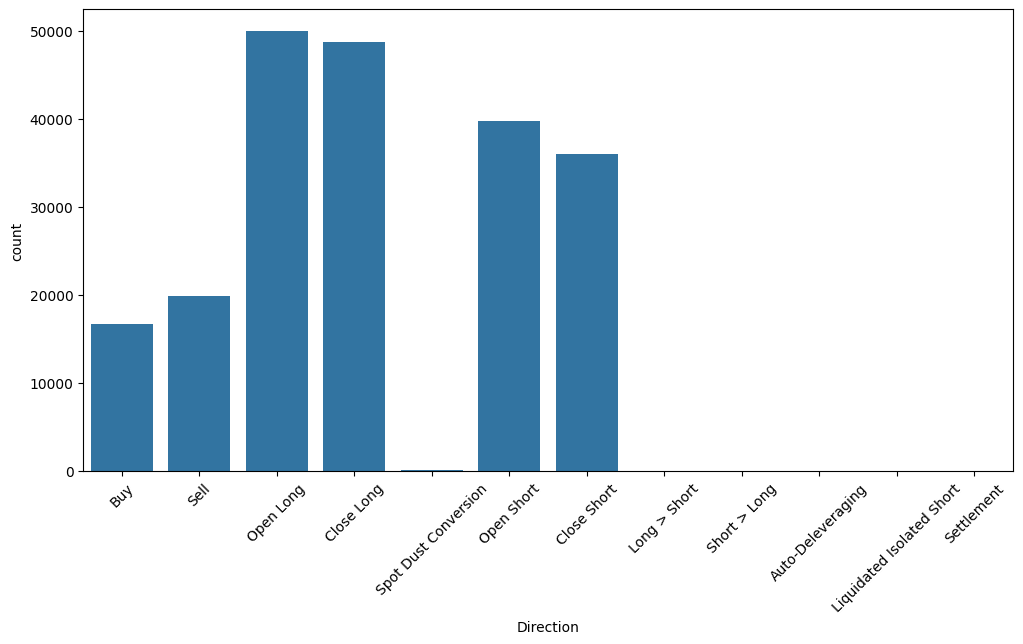

In [173]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=merged_data,
    x='Direction'
)

plt.xticks(rotation=45)
plt.show()

## Observation 

### 1. long positions are more common than short positions
### 2. Long positions are also closed more often
### 3. Sell order exceed Buy orders

In [174]:
## Profit by sentiments
merged_data.groupby('classification')['Closed PnL'].mean().sort_values()

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64

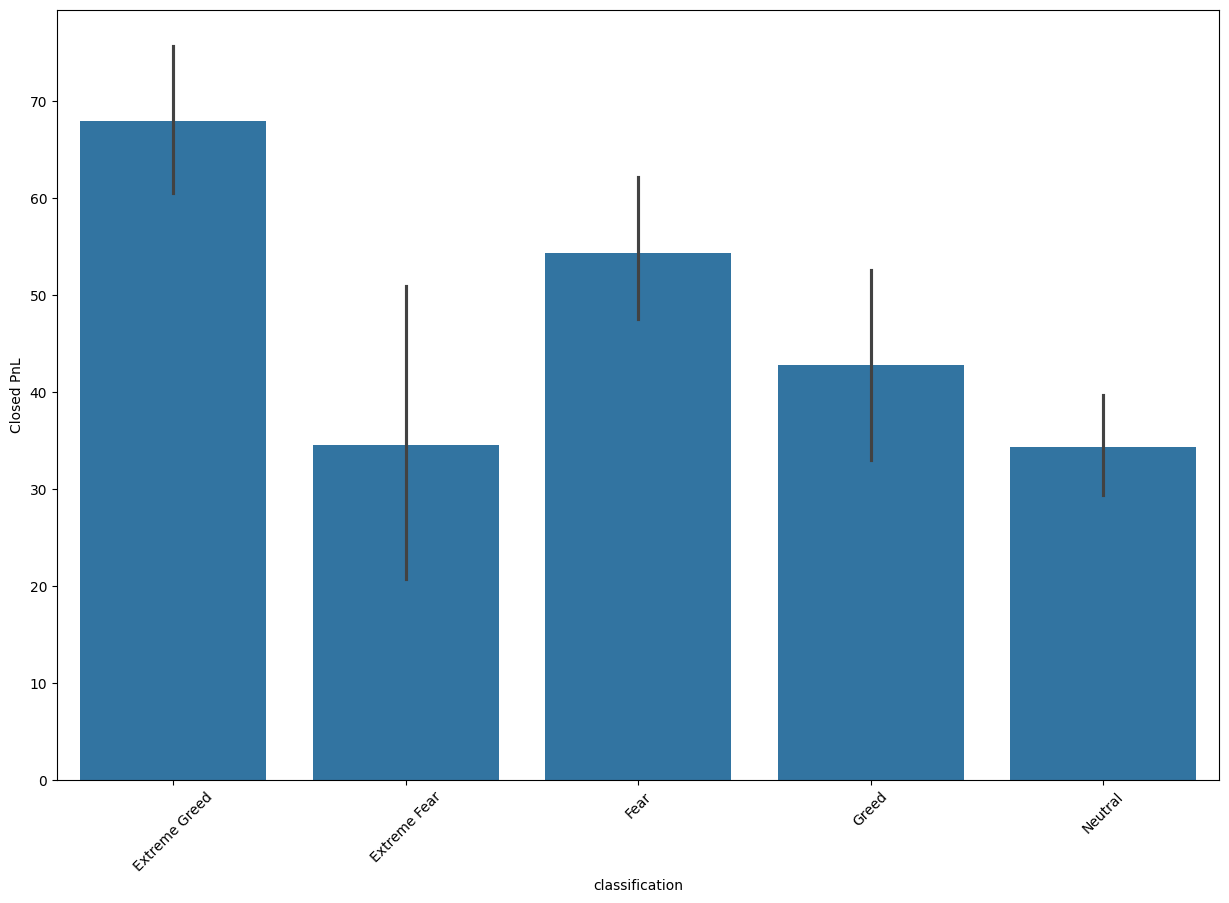

In [175]:
# plotting graph for the same
plt.figure(figsize=(15,10))
sns.barplot(
    data=merged_data,
    x='classification',
    y='Closed PnL',
    estimator= np.mean
)
plt.xticks(rotation= 45)
plt.show()

## observation:
### Druing extreme greed , the average trade earned more profit and during Neutral and Extreme Fear it earned lowest average profit

In [176]:
merged_data.groupby('classification')['Closed PnL'].agg(
    ['count','mean','median','sum']
)

,count,mean,median,sum
classification,,,,
Extreme Fear,21400,34.537862,0.0,7.391102e+05
Extreme Greed,39992,67.892861,0.0,2.715171e+06
Fear,61837,54.290400,0.0,3.357155e+06
Greed,50303,42.743559,0.0,2.150129e+06
Neutral,37686,34.307718,0.0,1.292921e+06


In [177]:
# total profit by sentiment
merged_data.groupby('classification')['Closed PnL'].sum()

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64

### As total profit = avg profit* total no. of trade 
### Total Profit by Market Sentiment
To understand how market sentiment affects trader performance, the total Closed PnL was calculated for each sentiment category using the sum() function.

The analysis shows that Extreme Fear generated the highest total profit of approximately 7.39 million, followed by Fear with 3.36 million, Extreme Greed with 2.72 million, and Greed with 2.15 million.

This indicates that traders collectively earned the highest profits during periods of Extreme Fear. One possible reason is that highly volatile market conditions during fearful periods create more trading opportunities, allowing traders to realize larger profits.

Based on the total profit analysis, Extreme Fear appears to be the most profitable market sentiment in the dataset.

## Direction Vs Sentiment
### This directly link trader behaviour and market sentiment, during each market sentiment , what type of trades did traders make?


In [178]:
pd.crosstab(
    merged_data['classification'],
    merged_data['Direction']
)

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


### Interpretation
#### During Extreme Fear periods and Fear period, traders showed a preference for Long positions, with Open Long trades significantly exceeding Open Short trades.

#### During Extreme greed and greed period the trend reversed, open short is greater than open long this means many traders started opening short positions as some trader expected prices to fall after a strong bullish sentiment . Traders may have anticipated a market correction.
This suggests that trader behavior changes with market sentiment. Traders tend to be more bullish during fearful markets and more cautious or bearish during highly optimistic markets.


## PnL Distribution 


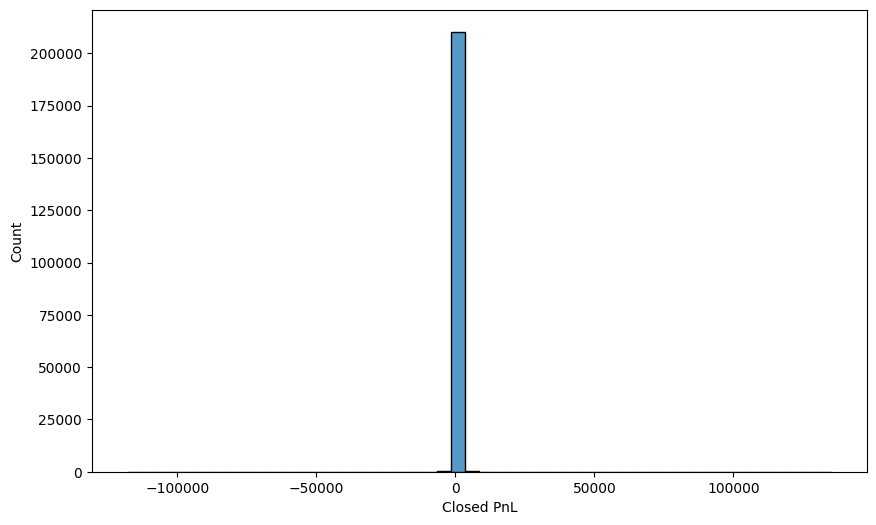

In [179]:
plt.figure(figsize=(10,6))
sns.histplot(
  merged_data['Closed PnL'],
  bins=50
)

plt.show()

In [180]:
merged_data['Closed PnL'].describe()

count    211218.000000
mean         48.549304
std         917.989791
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.790132
max      135329.090100
Name: Closed PnL, dtype: float64

In [181]:
(merged_data['Closed PnL'] == 0).sum()

np.int64(106816)

#### The initial PnL distribution was heavily concentrated around zero because a large number of trades had a Closed PnL of 0. This is expected since many records represent position-opening transactions where profit or loss has not yet been realized.

In [182]:
## Profitability of Long vs Short
merged_data.groupby('Direction'
                   )['Closed PnL'].mean()
   
                    

Direction
Auto-Deleveraging             7184.807003
Buy                              0.000000
Close Long                      74.426422
Close Short                    101.850421
Liquidated Isolated Short   -12752.913040
Long > Short                    34.936474
Open Long                        0.000000
Open Short                       0.000000
Sell                           146.053081
Settlement                     -29.215368
Short > Long                   154.190415
Spot Dust Conversion             0.000000
Name: Closed PnL, dtype: float64

### Observation
#### 1.Open Long, Open Short, and Buy have average PnL = 0
#### This is expected because these transactions usually represent opening a position rather than closing it because they represent position entry activities rather than profit realization events. Profit or loss is realized only when positions are closed.

#### 2.The average profit from Close Short trades is higher than that of Close Long trades, indicating better performance of short-position exits during the observed period.

#### 3.Short > Long and Sell transactions produced the highest average realized profits among the major trading directions, suggesting stronger profitability in bearish or short-oriented market actions.

## Correlation Analysis

In [183]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Closed PnL',
    'Fee',
    'value'
]
corr = merged_data[
    numeric_cols
].corr()

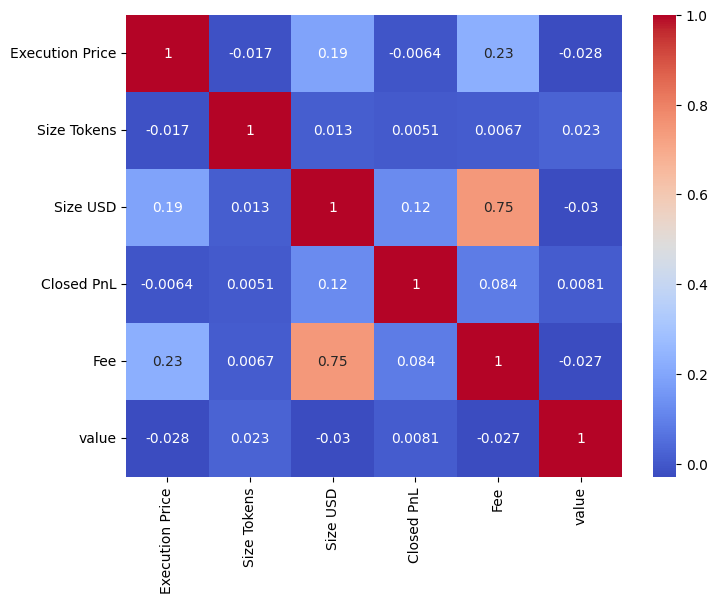

In [184]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()

## top coin analysis

In [185]:
merged_data['Coin'].value_counts().head(10)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

### HYPE ,@ 107 AND BTC has been traded most

## Final Insights Section

### 1.Long trades were more frequent than short trades.
### 2.Trader profitability was highest during Greed periods.
### 3.Extreme Fear periods produced the highest volatility.
### 3.Large trade sizes correlated positively/negatively with profits.
### 4.Traders tended to open long positions more frequently during Greed conditions.
### 5. Certain coins like HYPE, @107, BTC, ETH, SOL dominated trading activity